In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from scipy import signal
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter

# データの読み込み

## 歩行軌跡と歩行速度

In [9]:
trajectory_file_path = "./data/trajectory.csv"
speed_file_path = "./data/speed.csv"

# 通信してデータを取得
df_trajectory = pd.read_csv(trajectory_file_path)
df_speed = pd.read_csv(speed_file_path)

## データの描画

### 歩行軌跡

<Figure size 640x480 with 0 Axes>

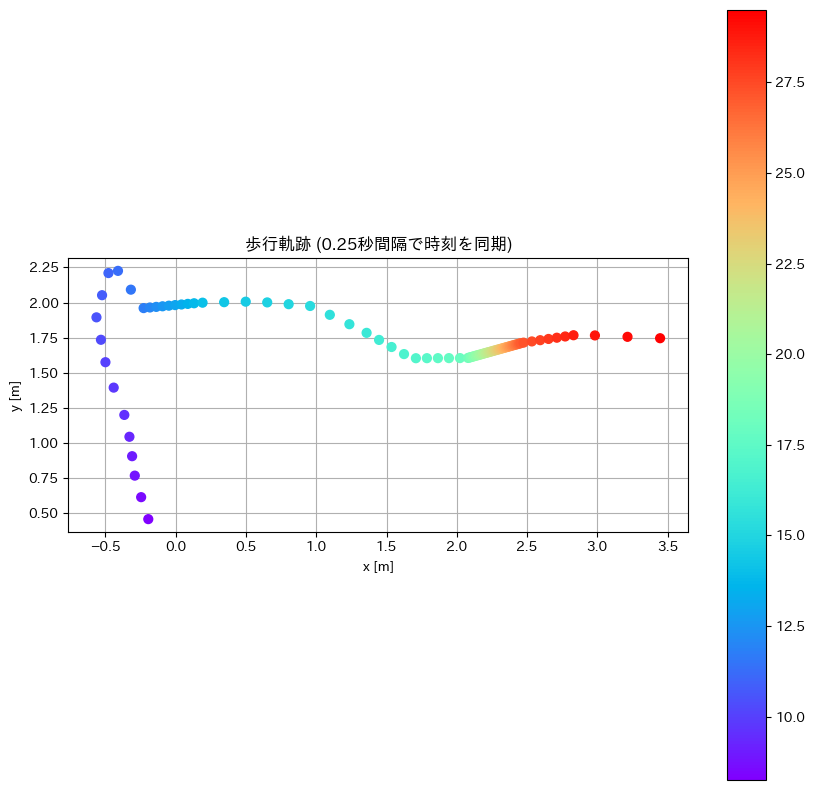

In [10]:
plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))



x = df_trajectory['x']
y = df_trajectory['y'] 
time = df_trajectory['time']

# 補間された軌跡を描画
plt.colorbar(plt.scatter(x, y,c=time,cmap='rainbow',s=40, label=f'推定軌跡', zorder=2))

plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (0.25秒間隔で時刻を同期)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)

plt.show()


## timeが15.0~27.0だけ抽出

<Figure size 640x480 with 0 Axes>

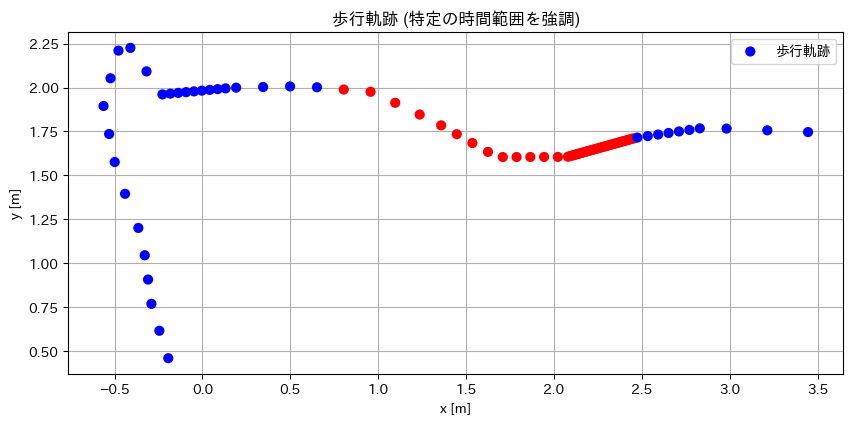

In [11]:
# timeが15秒から27秒の範囲にあるかどうかで色を決定
colors = np.where((df_trajectory['time'] >= 15) & (df_trajectory['time'] <= 27), 'red', 'blue')


plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))

# 特定の時間範囲の点を強調（例：赤色）
plt.scatter(df_trajectory['x'], df_trajectory['y'], c=colors, s=40, label='歩行軌跡', zorder=2)


plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (特定の時間範囲を強調)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)
plt.legend() # ラベルを表示するために凡例を追加
plt.show()

### 歩行速度

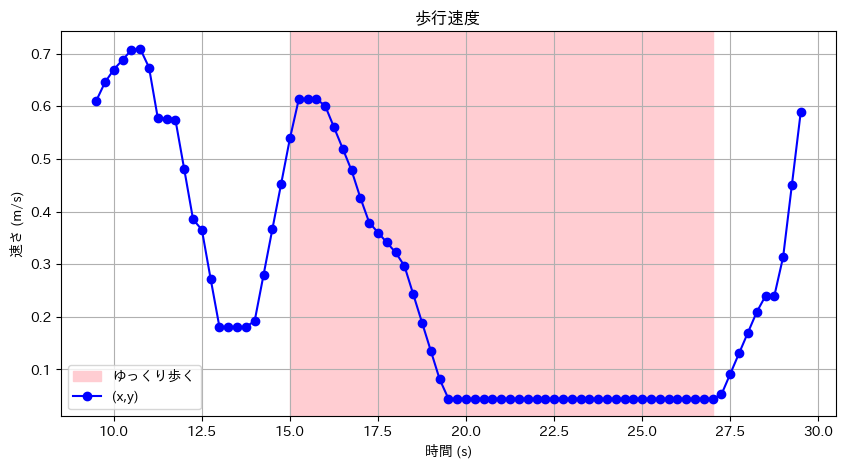

In [12]:
# ~speed.csvに1行目にデータ_足す(time,speed)[1]=(?,0)
# 軌跡と速度のtimeを同期するため
speed = df_speed['low_speed'] 
time = df_speed['time']
plt.figure(figsize=(10, 5))
plt.axvspan(15.0, 27.0,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.plot(time,speed, marker='o', linestyle='-', color='blue', label='(x,y)')
plt.xlabel('時間 (s)')
plt.ylabel('速さ (m/s)')
plt.title('歩行速度')
plt.grid(True)
plt.legend()

plt.show()

# データのラベル付け/抽出ロジック

     time         x         y     speed   stay
0    8.25 -0.194579  0.459881       NaN  False
1    8.50 -0.245373  0.616164  0.657321  False
2    8.75 -0.290661  0.769318  0.638838  False
3    9.00 -0.309677  0.907541  0.558099  False
4    9.25 -0.328693  1.045764  0.558099  False
..    ...       ...       ...       ...    ...
81  28.50  2.770779  1.759141  0.239677  False
82  28.75  2.830049  1.767937  0.239677  False
83  29.00  2.982370  1.766622  0.609306  False
84  29.25  3.214157  1.756672  0.928001  False
85  29.50  3.445944  1.746721  0.928001  False

[86 rows x 5 columns]


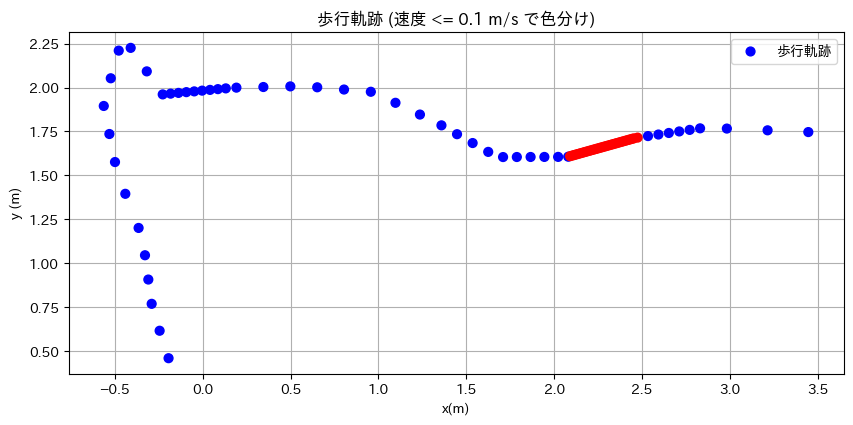

In [13]:
# 時間軸での同期: 歩行軌跡データと歩行速度データは、同じ時間点に対応しているか
df_trajectory = pd.merge(df_trajectory, df_speed[['time', 'speed']], on='time', how='left')

# 閾値の設定
# 条件判定: 歩行速度が設定された閾値以下であるか
threshold = 0.1
df_trajectory['stay'] = df_trajectory['speed'] <= threshold
print(df_trajectory)

colors_by_speed = np.where(df_trajectory['speed'] <= threshold, 'red', 'blue')

plt.figure(figsize=(10, 10))

# 閾値以下の場合、赤くそれ以外は青くプロット
plt.scatter(df_trajectory['x'], df_trajectory['y'], c=colors_by_speed, s=40, label='歩行軌跡', zorder=2)
df_trajectory.to_csv('data/threshold_trajectory_data.csv', index=False)

# 閾値以下の点をプロット
# plt.scatter(df_trajectory[df_trajectory['threshold_speed']]['x'],
#             df_trajectory[df_trajectory['threshold_speed']]['y'],
# 			c=colors_by_speed,
#             s=40, label=f'速度 <= {threshold} m/s', zorder=2)


plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x(m)')
plt.ylabel('y (m)')
plt.title(f'歩行軌跡 (速度 <= {threshold} m/s で色分け)')
plt.grid(True)
plt.legend()
plt.show()